In [ ]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

# sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
# import plotting_scripts as lrg_plot
# import importlib
# importlib.reload(lrg_plot)

In [ ]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [ ]:
cat0 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_basic.fits'))
cat = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_photom.fits'))
cat1 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_more_1.fits'))
cat = hstack([cat0, cat, cat1], join_type='exact')
print(len(cat))

In [ ]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

plt.figure(figsize=(15, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [ ]:
mask = cat['DEC']>-30
cat = cat[mask]
print(len(cat))

In [ ]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

plt.figure(figsize=(15, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

In [ ]:
lrg_opt = cat['SV1_DESI_TARGET'] & 2**3 > 0
print(np.sum(lrg_opt)/len(cat))

lrg_ir = cat['SV1_DESI_TARGET'] & 2**4 > 0
print(np.sum(lrg_ir)/len(cat))

In [ ]:
mask_qso = cat['SV1_DESI_TARGET'] & 2**2 > 0
print(np.sum(mask_qso)/len(cat))

In [9]:
mask = cat['MORPHTYPE']=='PSF'
print(np.sum(mask)/len(cat))

0.06464211433534764


In [10]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))

0.01354728080750108


In [122]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= cat['GAIA_PHOT_G_MEAN_MAG']<18
print(np.sum(mask)/len(cat))

0.00043985665805342433


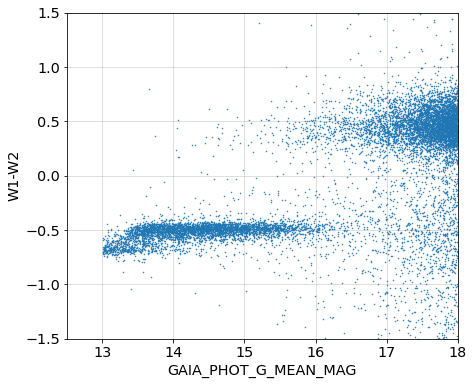

In [127]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

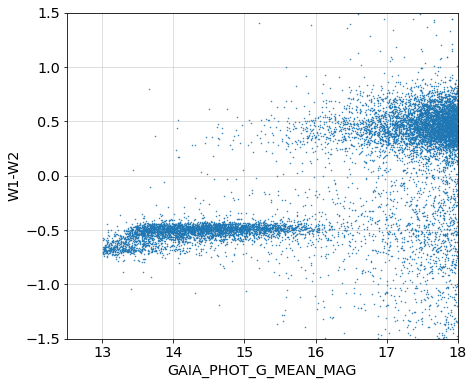

In [130]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

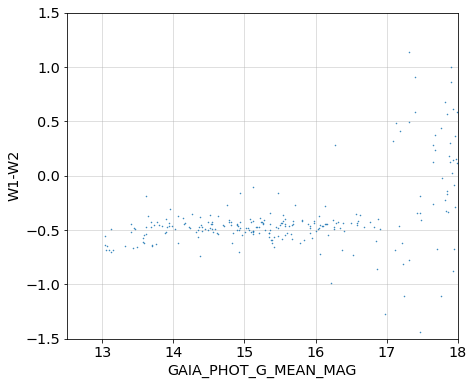

In [131]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>=10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

In [145]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 16)
mask &= (cat['w1mag']-cat['w2mag']>0)
print(np.sum(mask))

183


In [146]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)
mask &= (cat['w1mag']-cat['w2mag']>0)
print(np.sum(mask))

930


In [147]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask &= (cat['w1mag']-cat['w2mag']>0)
print(np.sum(mask))

5272


-------
## Overlap with BGS

In [152]:
bgs_bright = cat['SV1_BGS_TARGET'] & 2**1 > 0
print(np.sum(bgs_bright)/len(cat))

0.0841820868045725


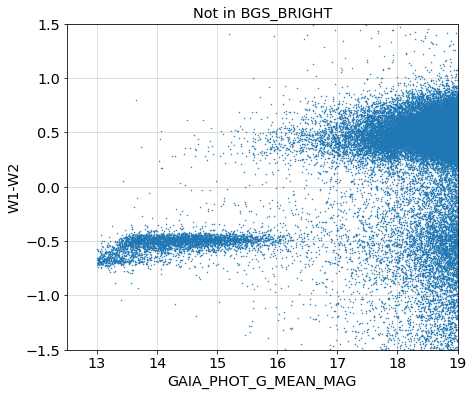

In [160]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 19)
mask &= (~bgs_bright)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.title("Not in BGS_BRIGHT")
plt.grid(alpha=0.5)
plt.axis([12.5, 19, -1.5, 1.5])
plt.show()

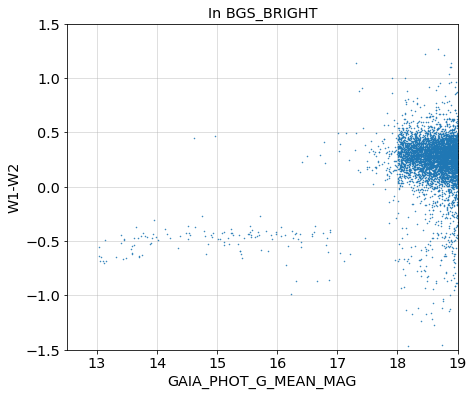

In [159]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 19)
mask &= (bgs_bright)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.title("In BGS_BRIGHT")
plt.grid(alpha=0.5)
plt.axis([12.5, 19, -1.5, 1.5])
plt.show()

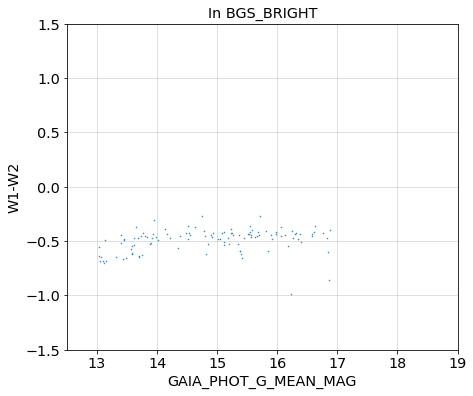

114
0


In [170]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)
mask &= (bgs_bright)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.title("In BGS_BRIGHT")
plt.grid(alpha=0.5)
plt.axis([12.5, 19, -1.5, 1.5])
plt.show()

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_bright_stars.txt', format='ascii.no_header', overwrite=True)

In [167]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 17) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask &= (cat['w1mag']-cat['w2mag']>0)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_agn_fainter.txt', format='ascii.no_header', overwrite=True)

4342
4320


---------

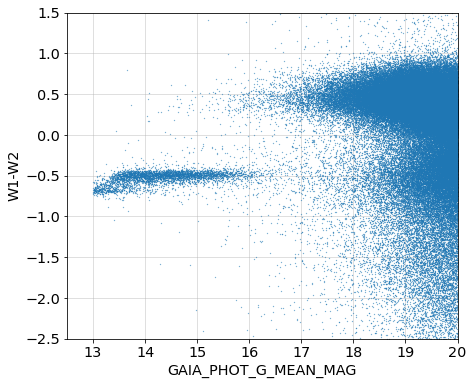

In [174]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

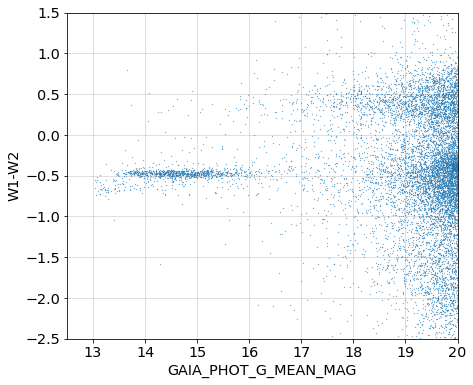

In [183]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask &= lrg_opt

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

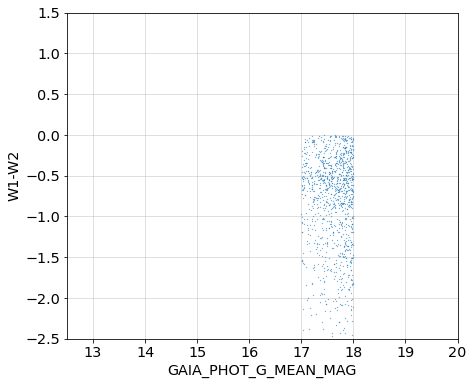

1148
1139


In [179]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 17) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask &= (cat['w1mag']-cat['w2mag']<0)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_bright_are_they_lrgs.txt', format='ascii.no_header', overwrite=True)

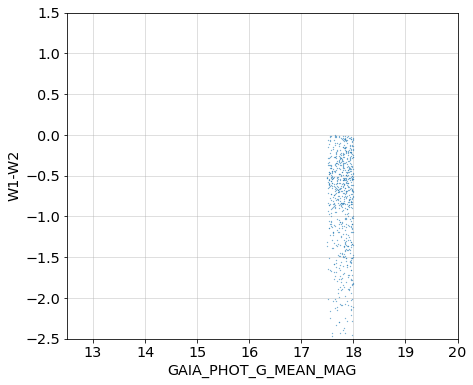

729
729


In [132]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 17.5) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask &= (cat['w1mag']-cat['w2mag']<0)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>500:
    idx = np.random.choice(idx, size=500, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_bright_are_they_lrgs_17.5_18.txt', format='ascii.no_header', overwrite=True)

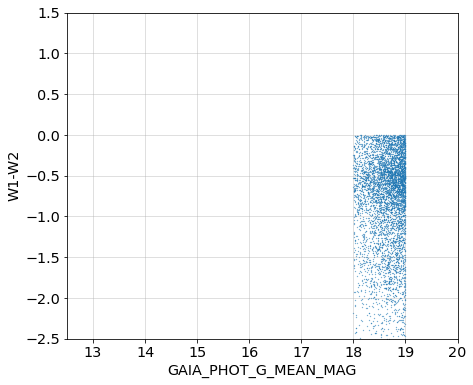

5502
5105


In [180]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 18) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 19)
mask &= (cat['w1mag']-cat['w2mag']<0)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_bright_are_they_lrgs_1.txt', format='ascii.no_header', overwrite=True)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

25611
19553


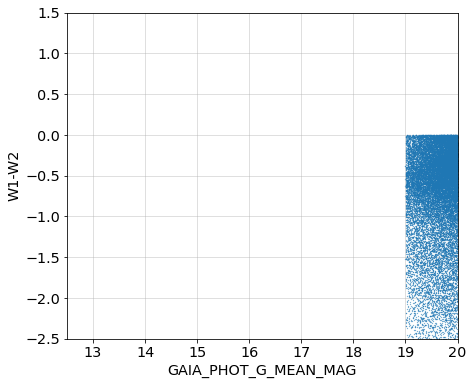

In [182]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 19) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask &= (cat['w1mag']-cat['w2mag']<0)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_bright_are_they_lrgs_2.txt', format='ascii.no_header', overwrite=True)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

--------

In [62]:
tt = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades/3/LRG/alltiles_LRGzinfo.fits'))
print(len(tt))

375701


In [63]:
mask = tt['subset']=='deep'
print(np.sum(mask)/len(mask))
tt = tt[mask]
print(len(tt))

mask = tt['TARGETS']=='QSO+LRG'
print(np.sum(mask)/len(mask))
tt = tt[mask]
print(len(tt))

0.15467885366288617
58113
0.6000034415707329
34868


In [64]:
# Remove FIBERSTATUS!=0 fibers
mask = tt['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
tt = tt[mask]

# Remove "no data" fibers
mask = tt['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
tt = tt[mask]

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05


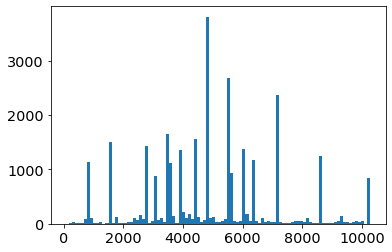

In [65]:
plt.hist(tt['EFFTIME_DARK'], 100);

In [66]:
mask = tt['EFFTIME_DARK']>2000
print(np.sum(mask)/len(mask))
tt = tt[mask]
print(len(tt))

0.8932924753149473
26236


In [67]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
cat1 = cat[mask].copy()
print(len(cat1))

mask = np.in1d(cat1['TARGETID'], tt['TARGETID'])
cat1 = cat1[mask]
print(len(cat1))

mask = np.in1d(tt['TARGETID'], cat1['TARGETID'])
tt = tt[mask]
print(len(tt))

128446
94
94


In [68]:
cat1 = join(cat1, tt[['TARGETID', 'Z', 'SPECTYPE']], keys='TARGETID')

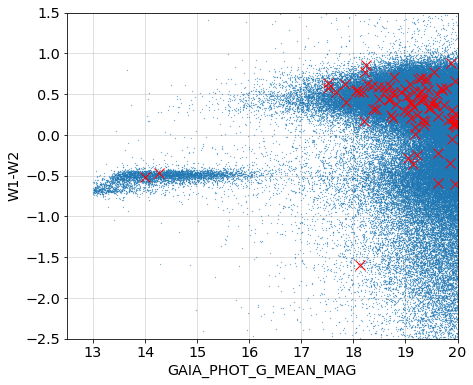

In [69]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG']), (cat1['w1mag']-cat1['w2mag']), 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

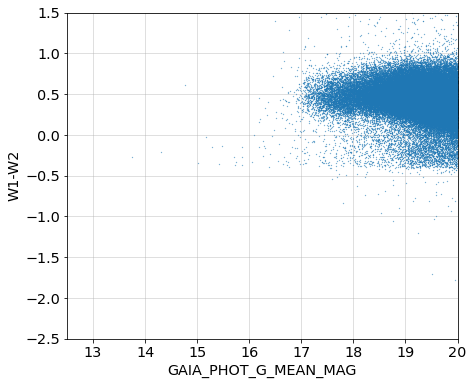

In [104]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask &= (qso)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
# plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG']), (cat1['w1mag']-cat1['w2mag']), 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

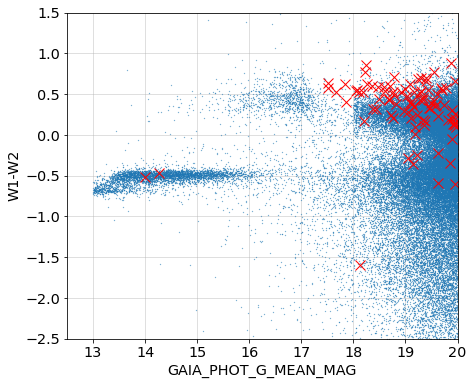

In [103]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask &= (~qso)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.5)
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG']), (cat1['w1mag']-cat1['w2mag']), 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.show()

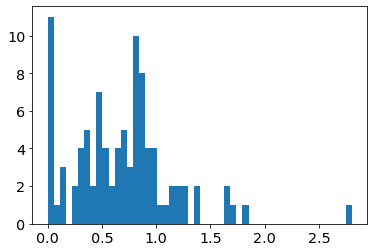

In [71]:
plt.hist(cat1['Z'], 50);

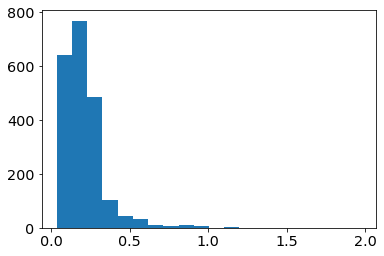

In [114]:
plt.hist(cat['Z_SPEC'][mask0], 20);

In [121]:
t = Table()
t['type'], t['count'] = np.unique(cat['SURVEY'][mask0], return_counts=True)
t.sort('count')
t


type,count
str10,int64
VVDS,1
eBOSS-ELG,1
DEEP2,4
OzDES,19
WiggleZ,26
2dFLenS,51
GAMA,244
BOSS,528
SDSS,1236


In [149]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask0 = mask & (cat['Z_SPEC']!=-99)
cat['Z_SPEC'][mask0]

0.30056876
0.09272693
0.3734391
0.2961073
0.23567067
0.22652157
0.27672738
0.26586673
0.23928566
0.23447186
0.1776333


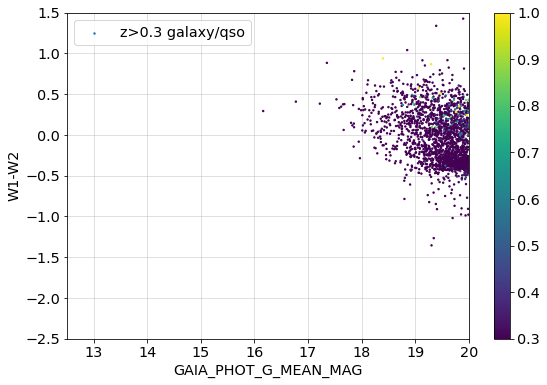

In [151]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask0 = mask & (cat['Z_SPEC']!=-99)

mask1 = (cat1['SPECTYPE']=='STAR') | (cat1['Z']<0.0001)
mask2 = (cat1['SPECTYPE']!='STAR') & (cat1['Z']<0.3)
mask3 = (cat1['SPECTYPE']!='STAR') & (cat1['Z']>0.3)

plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.scatter((cat['GAIA_PHOT_G_MEAN_MAG'])[mask0], (cat['w1mag']-cat['w2mag'])[mask0], s=2, c=cat['Z_SPEC'][mask0], cmap='viridis', vmin=0.3, vmax=1., zorder=3, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.legend()
plt.show()

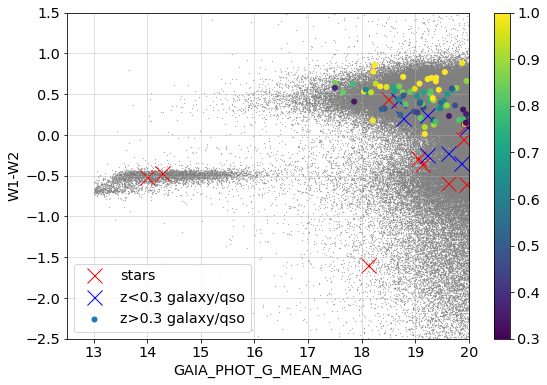

In [147]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat1['SPECTYPE']=='STAR') | (cat1['Z']<0.0001)
mask2 = (cat1['SPECTYPE']!='STAR') & (cat1['Z']<0.3)
mask3 = (cat1['SPECTYPE']!='STAR') & (cat1['Z']>0.3)

plt.figure(figsize=(9, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat1['w1mag']-cat1['w2mag'])[mask1], 'rx', ms=15, zorder=1, label='stars')
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask2], (cat1['w1mag']-cat1['w2mag'])[mask2], 'bx', ms=15, zorder=2, label='z<0.3 galaxy/qso')
plt.scatter((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask3], (cat1['w1mag']-cat1['w2mag'])[mask3], s=25, c=cat1['Z'][mask3], cmap='viridis', vmin=0.3, vmax=1., zorder=3, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.legend()
plt.show()

In [ ]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask & (~mask_qso)

mask1 = (~mask_qso1) & (cat1['SPECTYPE']=='STAR') | (cat1['Z']<0.0001)
mask2 = (~mask_qso1) & (cat1['SPECTYPE']!='STAR') & (cat1['Z']<0.3)
mask3 = (~mask_qso1) & (cat1['SPECTYPE']!='STAR') & (cat1['Z']>0.3)

plt.figure(figsize=(9, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat1['w1mag']-cat1['w2mag'])[mask1], 'rx', ms=15, zorder=1, label='stars')
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask2], (cat1['w1mag']-cat1['w2mag'])[mask2], 'bx', ms=15, zorder=2, label='z<0.3 galaxy/qso')
plt.scatter((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask3], (cat1['w1mag']-cat1['w2mag'])[mask3], s=25, c=cat1['Z'][mask3], cmap='viridis', vmin=0.3, vmax=1., zorder=3, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.legend()
plt.show()

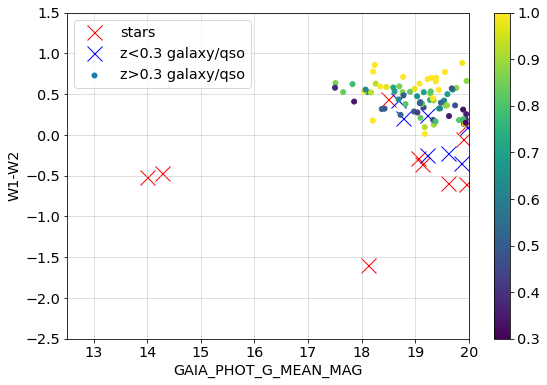

In [98]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat1['SPECTYPE']=='STAR') | (cat1['Z']<0.001)
mask2 = (cat1['SPECTYPE']!='STAR') & (cat1['Z']>0.001) & (cat1['Z']<0.3)
mask3 = (cat1['SPECTYPE']!='STAR') & (cat1['Z']>0.3)

plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat1['w1mag']-cat1['w2mag'])[mask1], 'rx', ms=15, zorder=1, label='stars')
plt.plot((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask2], (cat1['w1mag']-cat1['w2mag'])[mask2], 'bx', ms=15, zorder=2, label='z<0.3 galaxy/qso')
plt.scatter((cat1['GAIA_PHOT_G_MEAN_MAG'])[mask3], (cat1['w1mag']-cat1['w2mag'])[mask3], s=25, c=cat1['Z'][mask3], cmap='viridis', vmin=0.3, vmax=1., zorder=3, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.legend()
plt.show()

In [ ]:
mask_qso1 = cat1['SV1_DESI_TARGET'] & 2**2 > 0
print(np.sum(qso)/len(cat1))

In [152]:
len(cat)

24978592

In [153]:
cat['TARGETID'][0]

39627796804276553

In [158]:
from desitarget import targets

In [174]:
ls = Table(fitsio.read('/global/cfs/cdirs/desi/target/analysis/truth/dr9.0/south/matched/ls-dr9.0-sdss-specObj-dr16-unique-trimmed-match.fits', columns=['OBJID', 'BRICKID', 'RELEASE']))
truth = Table(fitsio.read('/global/cfs/cdirs/desi/target/analysis/truth/dr9.0/south/matched/sdss-specObj-dr16-unique-trimmed-match.fits', columns=['Z', 'ZWARNING']))
print(len(truth))

3141041


In [175]:
ls['TARGETID'] = targets.encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
truth = hstack([ls[['TARGETID']], truth])

In [176]:
mask = truth['ZWARNING']==0
truth = truth[mask]

In [177]:
mask = np.in1d(cat2['TARGETID'], truth['TARGETID'])
cat2 = cat2[mask]
print(len(cat2))

mask = np.in1d(truth['TARGETID'], cat2['TARGETID'])
truth = truth[mask]
print(len(truth))

1026507
1026507


In [178]:
cat2 = join(cat2, truth[['TARGETID', 'Z']], keys='TARGETID')

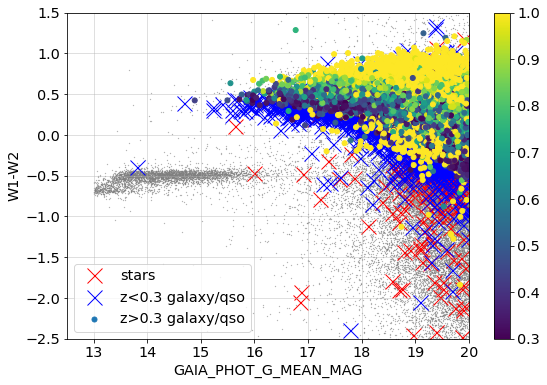

In [181]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']<0.0001) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask2 = (cat2['Z']>0.0001) & (cat2['Z']<0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask3 = (cat2['Z']>0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)

plt.figure(figsize=(9, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], 'rx', ms=15, zorder=1, label='stars')
plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask2], (cat2['w1mag']-cat2['w2mag'])[mask2], 'bx', ms=15, zorder=2, label='z<0.3 galaxy/qso')
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask3], (cat2['w1mag']-cat2['w2mag'])[mask3], s=25, c=cat2['Z'][mask3], cmap='viridis', vmin=0.3, vmax=1., zorder=3, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.legend(loc='lower left')
plt.show()

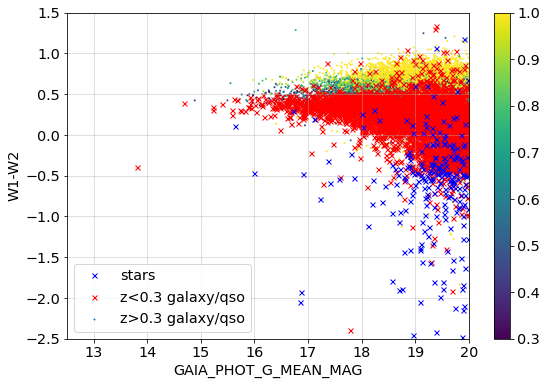

In [189]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']<0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask2 = (cat2['Z']>0.0003) & (cat2['Z']<0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask3 = (cat2['Z']>0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)

plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], 'bx', ms=5, zorder=2, label='stars')
plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask2], (cat2['w1mag']-cat2['w2mag'])[mask2], 'rx', ms=5, zorder=1, label='z<0.3 galaxy/qso')
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask3], (cat2['w1mag']-cat2['w2mag'])[mask3], s=1, c=cat2['Z'][mask3], cmap='viridis', vmin=0.3, vmax=1., zorder=0, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
plt.legend(loc='lower left')
plt.show()

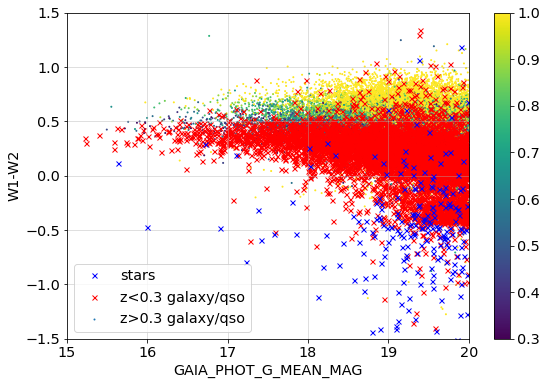

In [191]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']<0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask2 = (cat2['Z']>0.0003) & (cat2['Z']<0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask3 = (cat2['Z']>0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)

plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], 'bx', ms=5, zorder=2, label='stars')
plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask2], (cat2['w1mag']-cat2['w2mag'])[mask2], 'rx', ms=5, zorder=1, label='z<0.3 galaxy/qso')
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask3], (cat2['w1mag']-cat2['w2mag'])[mask3], s=1, c=cat2['Z'][mask3], cmap='viridis', vmin=0.3, vmax=1., zorder=0, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 20, -1.5, 1.5])
plt.legend(loc='lower left')
plt.show()

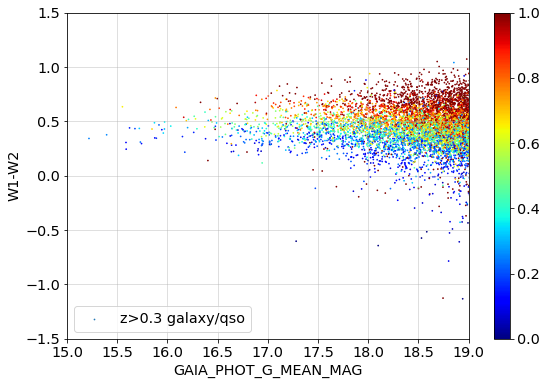

In [201]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']>0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask1 &= np.random.rand(len(cat2))>0.5

plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], s=0.5, c=cat2['Z'][mask1], cmap='jet', vmin=0., vmax=1., zorder=0, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 19, -1.5, 1.5])
plt.legend(loc='lower left')
plt.show()

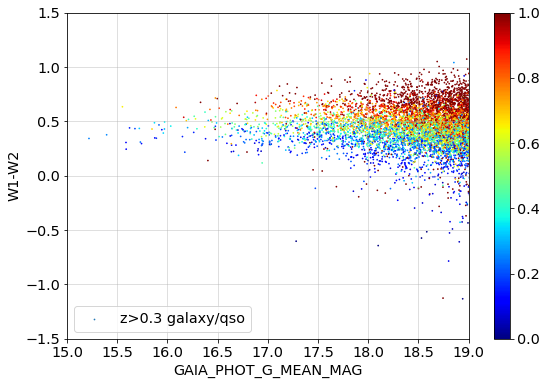

In [201]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']>0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask1 &= np.random.rand(len(cat2))>0.5

plt.figure(figsize=(9, 6))
# plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], s=0.5, c=cat2['Z'][mask1], cmap='jet', vmin=0., vmax=1., zorder=0, label='z>0.3 galaxy/qso')
plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([15., 19, -1.5, 1.5])
plt.legend(loc='lower left')
plt.show()

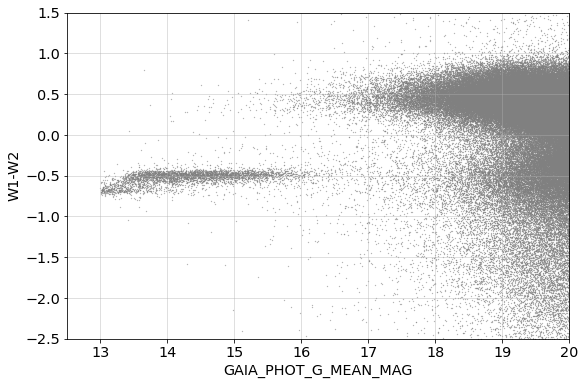

In [185]:
# No cut on GAIA_ASTROMETRIC_EXCESS_NOISE
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 20)

mask1 = (cat2['Z']<0.0003) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask2 = (cat2['Z']>0.0003) & (cat2['Z']<0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)
mask3 = (cat2['Z']>0.3) & (cat2['GAIA_PHOT_G_MEAN_MAG'] < 20)

plt.figure(figsize=(9, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', color='0.5', ms=0.5, zorder=0)
# plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat2['w1mag']-cat2['w2mag'])[mask1], 'rx', ms=5, zorder=1, label='stars')
# plt.plot((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask2], (cat2['w1mag']-cat2['w2mag'])[mask2], 'bx', ms=5, zorder=2, label='z<0.3 galaxy/qso')
# plt.scatter((cat2['GAIA_PHOT_G_MEAN_MAG'])[mask3], (cat2['w1mag']-cat2['w2mag'])[mask3], s=5, c=cat2['Z'][mask3], cmap='viridis', vmin=0.3, vmax=1., zorder=3, label='z>0.3 galaxy/qso')
# plt.colorbar()
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 20, -2.5, 1.5])
# plt.legend(loc='lower left')
plt.show()